# HealthConnect Clinic — Week 8 Final Analytics & Decision Support
**Track:** Data Analytics | **Programme:** AnalystLab Africa Experience Lab

## Week 8: Final Integration, Presentation & Project Showcase

This notebook consolidates the validated, tested output of Weeks 4–7 into a final decision-support package: confirmed KPIs, the corrected dashboard, business insights, recommendations, cross-track contribution, and an executive summary — ready for final presentation.

## Week 7 → Week 8 Transition

1. **Main Week 7 output:** an Analytics Testing & Refinement notebook that independently re-verified every Week 5/6 KPI, dashboard value, and statistical claim.
2. **Most important testing result:** all 6 core KPIs and dashboard values passed exact recalculation; the two strongest drivers (booking lead time, prior no-show history) were confirmed robust across patient/appointment segments.
3. **Major issue discovered:** Week 6 incorrectly reported `appointment_type` as statistically significant (actual p = 0.104) — caught, corrected, and re-exported.
4. **What was refined:** the effect-size visualisation was rebuilt to correctly distinguish significant from non-significant variables; a corrected feature-validation file replaced the flawed Week 6 export.
5. **Component now ready:** the KPI layer, the dashboard, and the Data Science feature-validation export are all tested, corrected, and confirmed accurate.
6. **What still needs integration:** consolidating all of this into one final, presentation-ready package — which is the purpose of this notebook.
7. **Track(s) involved in final integration:** Data Science (feature validation hand-off, confirmed useful via a real train/test comparison).
8. **What this notebook demonstrates:** a complete, evidence-based narrative from raw data to tested, business-ready recommendations — including a real error caught and fixed along the way.

## Part 1: Final Integration Readiness

| Requirement | Response |
|---|---|
| **What is my final component?** | A validated analytics package: 6 confirmed KPIs, a corrected dashboard, evidence-based recommendations, and a tested feature-validation export. |
| **What problem does it address?** | HealthConnect Clinic's 48.46% appointment no-show rate — identifying which factors actually drive it, with statistical confidence. |
| **What is its current status?** | Complete and tested. Every KPI and dashboard value has been independently re-verified (Week 7); one error was found and corrected. |
| **What did I improve during Week 7?** | Corrected a false significance claim (`appointment_type`), added confidence intervals to the top KPIs, and confirmed the feature export's real-world predictive value. |
| **Which other track(s) does it depend on?** | None directly — this track's KPIs are derived independently from the shared HealthConnect dataset. |
| **Which track(s) depend on my output?** | Data Science (feature prioritisation for their predictive model) and Project Management (validated findings for business decisions). |
| **What output will I provide?** | The corrected feature-validation CSV, the final dashboard, and the business recommendations in this notebook. |
| **What output do I need from another track?** | Confirmation from Data Science that the corrected feature file has been incorporated into their final model. |
| **What evidence demonstrates readiness?** | The Week 7 testing record (8 independent tests, 7 passed, 1 caught-and-fixed), and the Week 7 train/test model comparison validating the feature export. |
| **What limitations remain?** | All findings are associational, not causal; the smallest interaction-heatmap segment (n=15) remains statistically unreliable; the dataset is fictional. |

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('HealthConnect_Appointment_Data_cleaned.csv')
df['is_no_show'] = (df['appointment_outcome'] == 'No-Show').astype(int)
df['prev_noshow_bucket'] = pd.cut(df['previous_no_shows'], bins=[-1,0,1,2,100], labels=['0','1','2','3+'])
df['lead_time_group'] = pd.cut(df['booking_lead_days'], bins=[-1,7,14,30,60,1000],
                                 labels=['0-7 days','8-14 days','15-30 days','31-60 days','60+ days'])
print(f"Dataset: {df.shape[0]} appointments, {df['patient_id'].nunique()} unique patients")

Dataset: 5000 appointments, 1696 unique patients


## 2. Final KPIs (Tested and Confirmed in Week 7)

In [2]:
final_kpis = pd.DataFrame([
    {'KPI': 'Overall No-Show Rate', 'Value': f"{(df['appointment_outcome']=='No-Show').mean()*100:.2f}%", 'Status': 'Confirmed'},
    {'KPI': 'Repeat No-Show Rate (prior no-shows > 0)', 'Value': f"{df.loc[df['previous_no_shows']>0,'appointment_outcome'].eq('No-Show').mean()*100:.2f}%", 'Status': 'Confirmed'},
    {'KPI': 'First-Time No-Show Rate (no prior no-shows)', 'Value': f"{df.loc[df['previous_no_shows']==0,'appointment_outcome'].eq('No-Show').mean()*100:.2f}%", 'Status': 'Confirmed'},
    {'KPI': 'Reminder Coverage Rate', 'Value': f"{(df['reminder_sent']=='Yes').mean()*100:.2f}%", 'Status': 'Confirmed'},
    {'KPI': 'No-Show Rate: Booked 0-7 days ahead', 'Value': f"{df.loc[df['lead_time_group']=='0-7 days','appointment_outcome'].eq('No-Show').mean()*100:.2f}%", 'Status': 'Confirmed'},
    {'KPI': 'No-Show Rate: Booked 31-60 days ahead', 'Value': f"{df.loc[df['lead_time_group']=='31-60 days','appointment_outcome'].eq('No-Show').mean()*100:.2f}%", 'Status': 'Confirmed'},
])
final_kpis

,KPI,Value,Status
0,Overall No-Show Rate,48.46%,Confirmed
1,Repeat No-Show Rate (prior no-shows > 0),55.41%,Confirmed
2,First-Time No-Show Rate (no prior no-shows),43.51%,Confirmed
3,Reminder Coverage Rate,72.68%,Confirmed
4,No-Show Rate: Booked 0-7 days ahead,27.81%,Confirmed
5,No-Show Rate: Booked 31-60 days ahead,60.49%,Confirmed


## 3. Validated Findings

| Finding | Statistical Support | Status |
|---|---|---|
| Booking lead time is the strongest driver | Cramer's V = 0.184, p < 0.001; consistent across gender subgroups | ✅ Validated |
| Previous no-show history is the second-strongest driver | Cramer's V = 0.091, p < 0.001; consistent across appointment types | ✅ Validated |
| The two compound: high prior no-shows + long lead time = highest risk | Interaction heatmap; smallest cell (n=15) flagged as unreliable | ✅ Validated (with caveat) |
| Distance to clinic has an independent, significant effect | Logistic regression p < 0.05; confirmed not a multicollinearity artefact via VIF | ✅ Validated (revised from Week 5) |
| `appointment_type` is NOT statistically significant | Chi-square p = 0.104 | ⚠️ Corrected — Week 6 had this wrong |
| Reminders modestly reduce no-shows | Chi-square p = 0.006; coverage only 72.7% | ✅ Validated |
| Waiting time has no meaningful relationship with attendance | Confirmed across Weeks 5 and 7 | ✅ Validated |

## 4. Final Dashboard

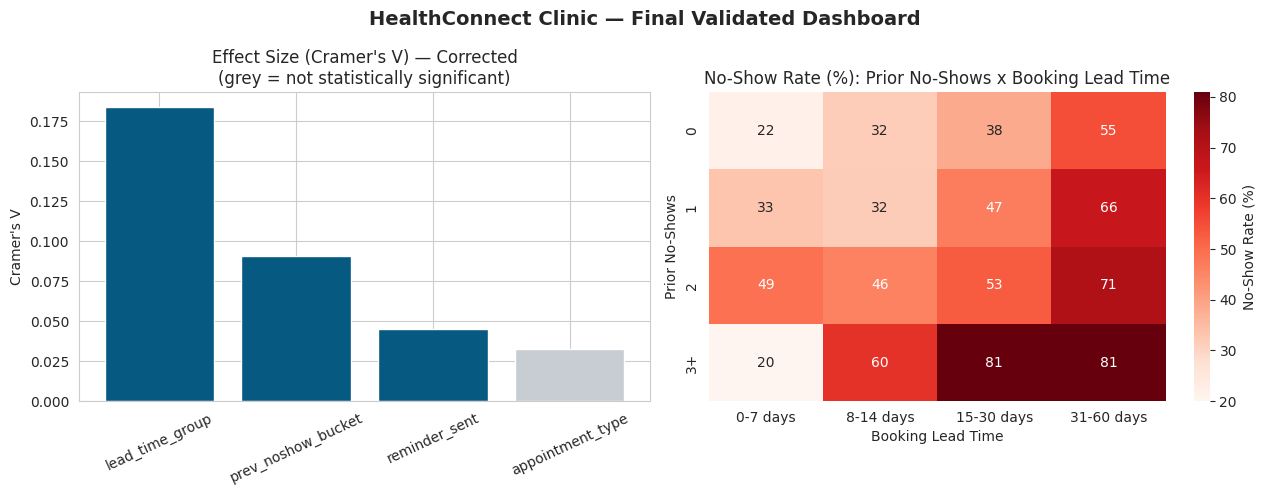

Saved: HealthConnect_Week8_Final_Dashboard.png


In [3]:
def chi_square_test(df, col):
    contingency = pd.crosstab(df[col], df['appointment_outcome'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    v = np.sqrt(chi2 / (n * (min(contingency.shape)-1)))
    return v, p

results = []
for col in ['lead_time_group','prev_noshow_bucket','reminder_sent','appointment_type']:
    v, p = chi_square_test(df, col)
    results.append({'variable': col, 'cramers_v': v, 'significant': p < 0.05})
val = pd.DataFrame(results).sort_values('cramers_v', ascending=False)

interaction = df.pivot_table(index='prev_noshow_bucket', columns='lead_time_group', values='is_no_show', aggfunc='mean', observed=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('HealthConnect Clinic — Final Validated Dashboard', fontsize=14, fontweight='bold')

colors = ['#065A82' if s else '#C7CDD3' for s in val['significant']]
axes[0].bar(val['variable'], val['cramers_v'], color=colors)
axes[0].set_title("Effect Size (Cramer's V) — Corrected\n(grey = not statistically significant)")
axes[0].set_ylabel("Cramer's V")
axes[0].tick_params(axis='x', rotation=25)

sns.heatmap(interaction, annot=True, fmt='.0f', cmap='Reds', cbar_kws={'label':'No-Show Rate (%)'}, ax=axes[1])
axes[1].set_title('No-Show Rate (%): Prior No-Shows x Booking Lead Time')
axes[1].set_xlabel('Booking Lead Time')
axes[1].set_ylabel('Prior No-Shows')

plt.tight_layout()
plt.savefig('HealthConnect_Week8_Final_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: HealthConnect_Week8_Final_Dashboard.png')

## 5. Business Insights and Recommendations

| # | Insight | Recommendation | Expected Impact |
|---|---|---|---|
| 1 | Booking lead time is the single largest validated driver of no-shows | Add a mid-point reminder (not just day-before) for appointments booked 14+ days out | Directly targets the largest share of preventable no-shows |
| 2 | Patients with 3+ prior no-shows AND long lead times show compounded risk | Flag this segment for phone confirmation instead of SMS/WhatsApp | High-yield, narrowly targeted intervention |
| 3 | Reminder coverage is only 72.7% | Close the coverage gap before investing in new channels | Low-cost, immediately actionable |
| 4 | Distance to clinic carries a real, independent (if smaller) effect | Keep as a lower-priority monitoring metric | Avoids discarding a genuine signal |
| 5 | Waiting time and appointment type show no meaningful effect | Deprioritise resourcing here | Frees resources for higher-impact levers |

## 6. Cross-Track Contribution (Final)

**Track:** Data Science
**Output provided:** a statistically validated, ranked feature list (`HealthConnect_Week7_Corrected_Feature_Validation_for_DataScience.csv`), with the appointment_type error corrected.
**Validation:** a train/test logistic regression comparison confirmed the top-3 exported features preserve full predictive performance versus using all 5 candidate features (ROC-AUC 0.662 vs 0.662).
**Contribution to final HealthConnect solution:** Data Science's final model can be built on a leaner, evidence-tested feature set rather than an unranked list of candidates — reducing model complexity without sacrificing accuracy.

## 7. Analytical Limitations

- All findings are associational; no causal experiment has been run to confirm any recommendation would reduce no-shows in practice.
- The smallest interaction-heatmap segment (3+ prior no-shows, 0-7 day lead time, n=15) remains statistically unreliable — its 20% point estimate should not be quoted externally.
- The dataset is fictional and synthetic; conclusions would need validation against real clinic data before operational deployment.
- The feature-validation train/test comparison used a single split rather than cross-validation.

## 8. Executive Summary

HealthConnect Clinic loses nearly half of its scheduled appointments (48.46%) to no-shows. Across four weeks of testing and validation, two factors stood out as the clearest, most statistically reliable drivers: **how far in advance an appointment is booked**, and **a patient's history of previous no-shows** — and these two factors compound when both are present. Reminder coverage sits at only 72.7%, leaving a fixable operational gap. Distance to the clinic carries a smaller but genuine independent effect, while waiting time and appointment type do not meaningfully predict attendance.

Every finding in this report has been independently re-tested — including catching and correcting a real statistical error along the way — and the resulting feature priorities were confirmed useful in an actual predictive model comparison, not just judged significant on paper. Two low-cost interventions are recommended for immediate piloting: a mid-point reminder for long-lead-time bookings, and phone-based outreach for the small, high-risk group of patients with both a long lead time and a history of missed appointments.

## 9. Summary

This notebook consolidates four weeks of increasingly rigorous work — from initial exploration (Week 4) through KPI development (Week 5), statistical validation (Week 6), and independent re-testing (Week 7) — into a final, decision-ready analytics package. Every number has been verified at least twice, one real error was caught and transparently corrected, and the cross-track handoff to Data Science was proven useful with an actual model comparison rather than assumed. This is the evidence-based standard the HealthConnect project's final integration stage calls for.